In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.weightstats import ztest
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings('ignore')

In [19]:
df=pd.read_csv(r"/content/ab_testing (1).csv")

In [20]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [21]:
df.isna().sum()

,0
User ID,0
Group,0
Page Views,0
Time Spent,0
Conversion,0
Device,0
Location,0


In [22]:
print(df.shape)
df.info()

(5000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [23]:
df.describe()



,User ID,Page Views,Time Spent
count,5000.000000,5000.000000,5000.000000
mean,14925.159000,7.537600,242.512600
std,2869.153773,4.022465,118.254153
min,10001.000000,1.000000,40.000000
25%,12456.250000,4.000000,137.000000
50%,14858.500000,8.000000,243.000000
75%,17379.750000,11.000000,346.000000
max,19995.000000,14.000000,449.000000


In [24]:
df.describe(include='object')

,Group,Conversion,Device,Location
count,5000,5000,5000,5000
unique,2,2,2,4
top,A,No,Desktop,Scotland
freq,2519,4515,2538,1281


In [25]:
df.groupby('Group')['Conversion'].value_counts(normalize=True)

Group  Conversion
A      No            0.946010
       Yes           0.053990
B      No            0.859331
       Yes           0.140669
Name: proportion, dtype: float64

In [26]:
conv_rate = df[df['Conversion'] == 'Yes'].groupby('Group')['User ID'].count() / df.groupby('Group')['User ID'].count()
print(conv_rate)

Group
A    0.053990
B    0.140669
Name: User ID, dtype: float64


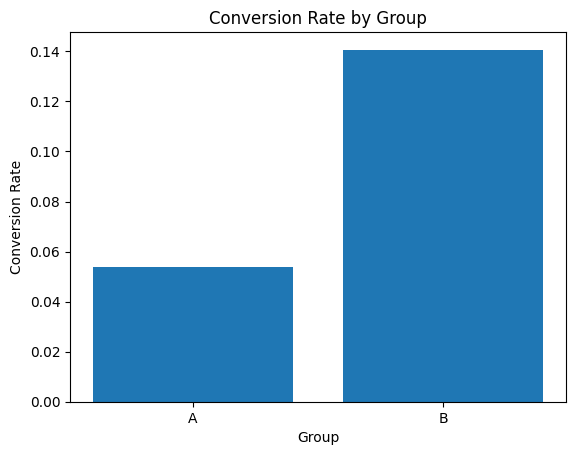

In [27]:
plt.bar(conv_rate.index, conv_rate.values)
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Group')
plt.show()


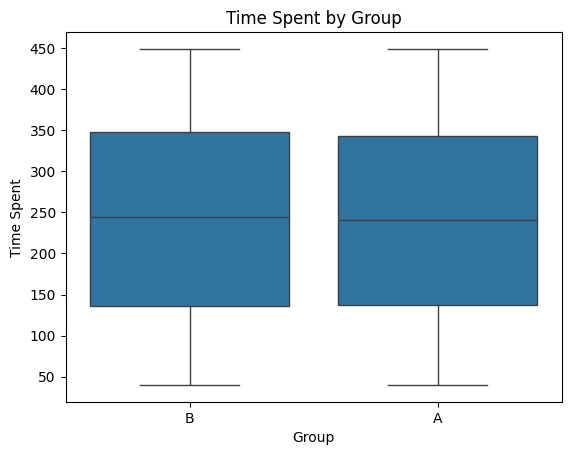

In [28]:
sns.boxplot(data=df, x='Group', y='Time Spent')
plt.title('Time Spent by Group')
plt.show()

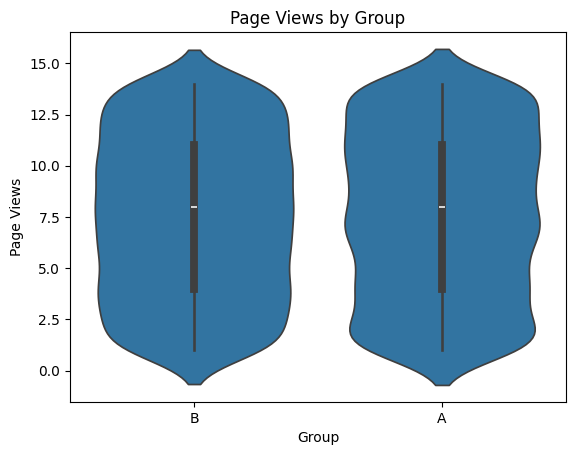

In [29]:
sns.violinplot(data=df, x='Group', y='Page Views')
plt.title('Page Views by Group')
plt.show()

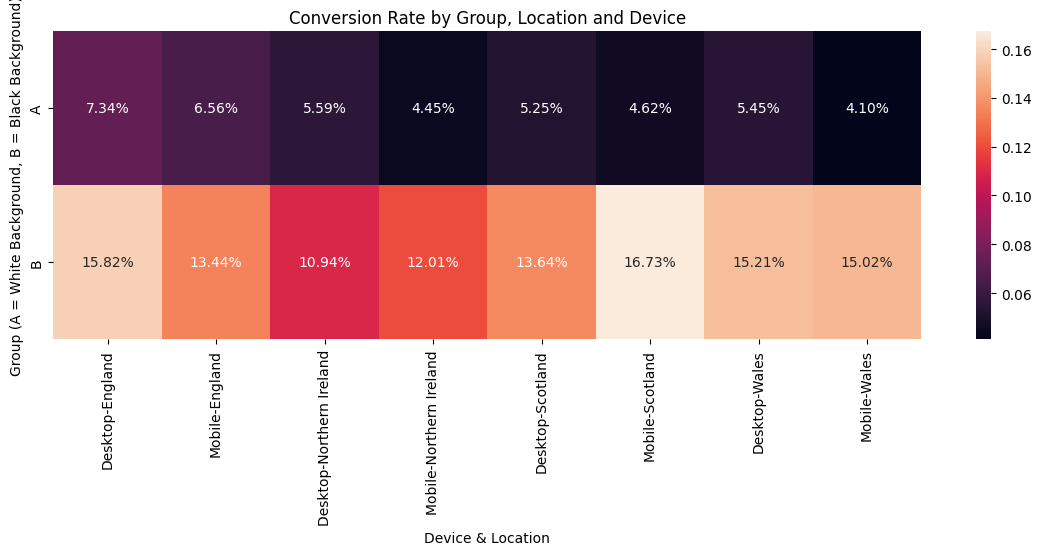

In [30]:
df['Converted'] = (df['Conversion'] == 'Yes').astype(int)
pivot_table = df.groupby(['Group', 'Location', 'Device'])['Converted'].mean().unstack(['Device', 'Location'])

plt.figure(figsize=(14, 4))
sns.heatmap(pivot_table, annot=True, fmt='.2%')
plt.title('Conversion Rate by Group, Location and Device')
plt.xlabel('Device & Location')
plt.ylabel('Group (A = White Background, B = Black Background)')
plt.show()

In [31]:
contingency_table = pd.crosstab(df['Group'], df['Conversion'])
print(contingency_table)

Conversion    No  Yes
Group                
A           2383  136
B           2132  349


In [32]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print('p-value:', p_value)

p-value: 6.571736018334222e-25


In [33]:
group_a = df[df['Group'] == 'A']['Time Spent']
group_b = df[df['Group'] == 'B']['Time Spent']

z_stat, p_value = ztest(group_a, group_b)
print('p-value:', p_value)

p-value: 0.6386775680364083


In [34]:
group_a = df[df['Group'] == 'A']['Page Views']
group_b = df[df['Group'] == 'B']['Page Views']

z_stat, p_value = ztest(group_a, group_b)
print('p-value:', p_value)

p-value: 0.43598597900800473


In [35]:
conversions = df.groupby('Group')['Conversion'].apply(lambda x: (x == 'Yes').sum()).values
total = df.groupby('Group')['Conversion'].count().values

z_stat, p_value = proportions_ztest(conversions, total)
print('z-stat:', z_stat)
print('p-value:', p_value)

z-stat: -10.354488520266216
p-value: 3.9931511894201938e-25
